In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import pickle

# MultiColumnLabelEncoder class (replaces the missing pip package)
class MultiColumnLabelEncoder:
    """Label encoder that works on multiple columns of a pandas DataFrame."""
    def __init__(self, columns=None):
        self.columns = columns
        self.encoders = {}

    def fit(self, X, y=None): 
        
        if self.columns is None:
            self.columns = [c for c in X.columns if X[c].dtype == 'object' or str(X[c].dtype).startswith('category')]
        for col in self.columns:
            le = LabelEncoder()
            le.fit(X[col].astype(str))
            self.encoders[col] = le
        return self

    def transform(self, X):
        output = X.copy()
        for col, le in self.encoders.items():
            output[col] = le.transform(output[col].astype(str))
        return output

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

In [106]:
data = pd.read_csv("../Dataset/garments_worker_productivity.csv")

In [107]:
data.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

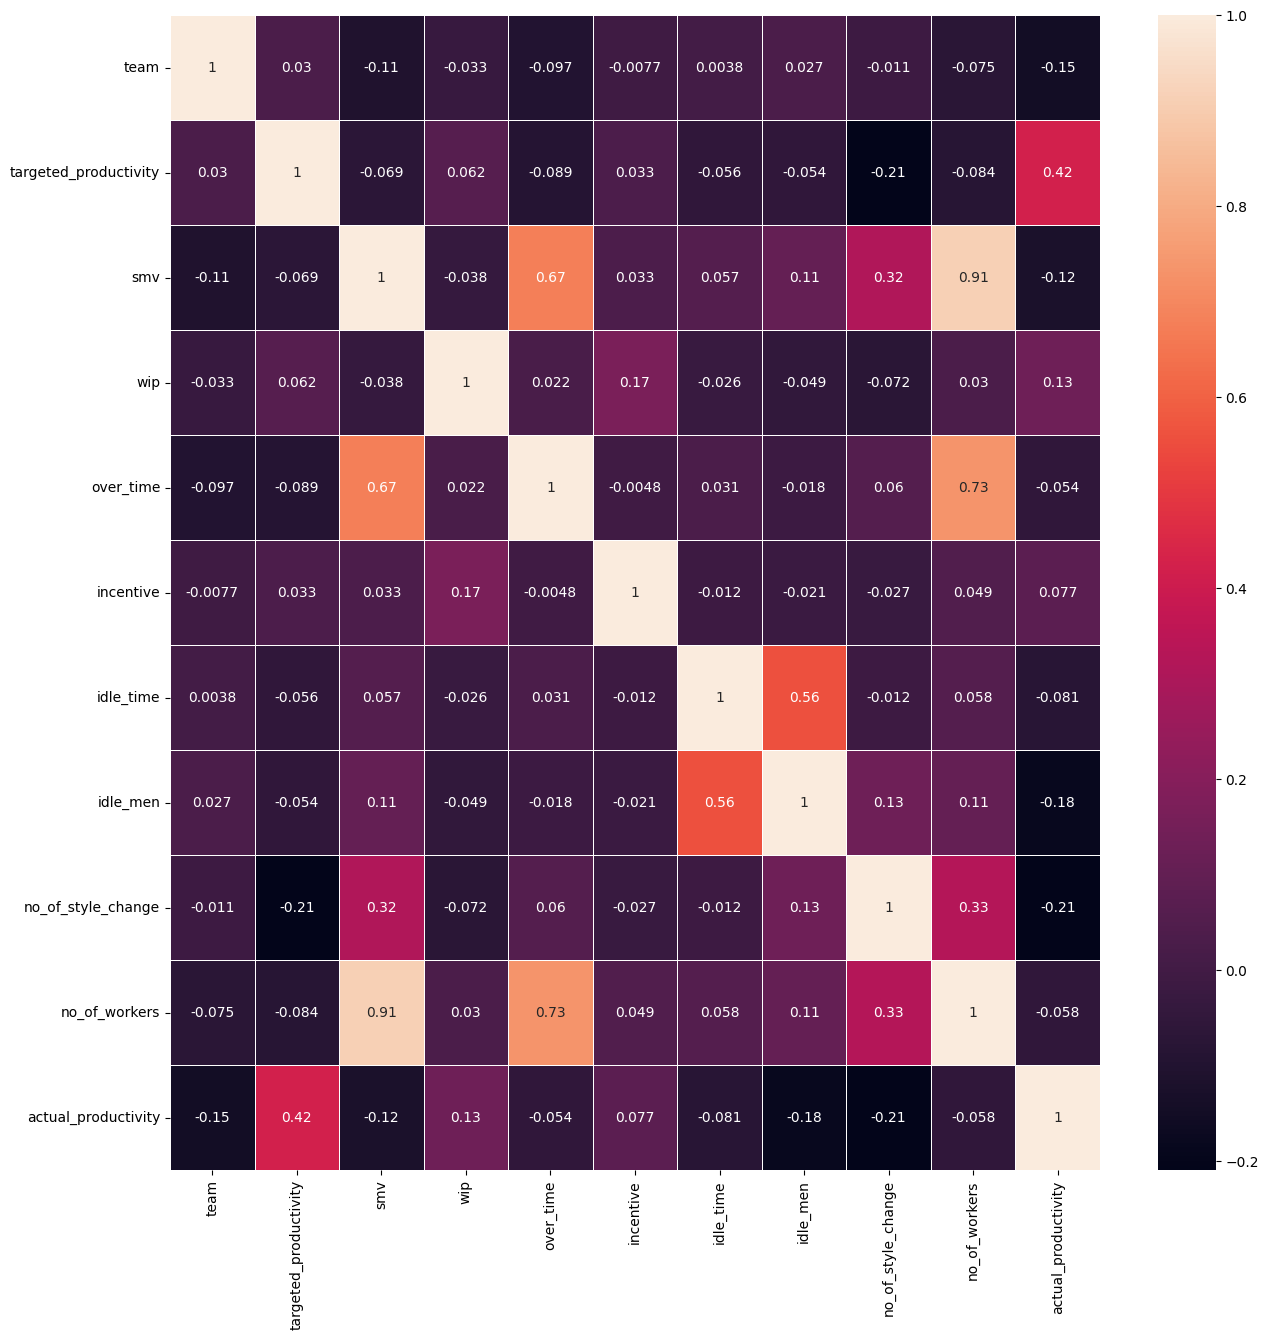

In [109]:
numeric_data = data.select_dtypes(include=['number'])
corrMatrix = numeric_data.corr()
fig, ax = plt.subplots(figsize=(15,15))
sns.heatmap(corrMatrix, annot=True, linewidths =.5, ax=ax)
plt.show()

In [110]:
data.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


In [111]:
data.shape

(1197, 15)

In [112]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

In [113]:
data.isnull().sum()

date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

In [114]:
data.drop(['wip'],axis=1,inplace=True)

In [115]:
data['date'] = pd.to_datetime(data['date'])

In [116]:
data.date

0      2015-01-01
1      2015-01-01
2      2015-01-01
3      2015-01-01
4      2015-01-01
          ...    
1192   2015-03-11
1193   2015-03-11
1194   2015-03-11
1195   2015-03-11
1196   2015-03-11
Name: date, Length: 1197, dtype: datetime64[ns]

In [117]:
data['month']= data['date'].dt.month

In [118]:
data.drop(['date'],axis=1,inplace=True)

In [119]:
data.month

0       1
1       1
2       1
3       1
4       1
       ..
1192    3
1193    3
1194    3
1195    3
1196    3
Name: month, Length: 1197, dtype: int32

In [120]:
data['department'].value_counts()

department
sweing        691
finishing     257
finishing     249
Name: count, dtype: int64

In [121]:
# Finishing department is split into 2, we will merge them into 1
data['department'] = data['department'].apply(lambda x: 'finishing' if x.replace(" ","") == 'finishing' else 'sweing' )
data['department'].value_counts()

department
sweing       691
finishing    506
Name: count, dtype: int64

In [122]:
# Use the MultiColumnLabelEncoder class defined in Cell 1
Mcle = MultiColumnLabelEncoder()
data = Mcle.fit_transform(data)

In [123]:
x=data.drop(['actual_productivity'],axis=1)
y=data['actual_productivity']

In [124]:
X=x.to_numpy()

In [125]:
X

array([[ 0. ,  1. ,  3. , ...,  0. , 59. ,  1. ],
       [ 0. ,  0. ,  3. , ...,  0. ,  8. ,  1. ],
       [ 0. ,  1. ,  3. , ...,  0. , 30.5,  1. ],
       ...,
       [ 1. ,  0. ,  5. , ...,  0. ,  8. ,  3. ],
       [ 1. ,  0. ,  5. , ...,  0. , 15. ,  3. ],
       [ 1. ,  0. ,  5. , ...,  0. ,  6. ,  3. ]], shape=(1197, 13))

In [126]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [127]:
from sklearn.linear_model import LinearRegression
model_lr=LinearRegression()

In [128]:
model_lr.fit(x_train, y_train)
pred_test=model_lr.predict(x_test)
print("test_MSE :", mean_squared_error(y_test, pred_test))
print("test_MAE : ", mean_absolute_error(y_test, pred_test))
print("R2_score: {}".format(r2_score(y_test, pred_test)))

test_MSE : 0.02095295476187553
test_MAE :  0.10636001215549977
R2_score: 0.29131231547755876


In [129]:
from sklearn.ensemble import RandomForestRegressor
model_rf=RandomForestRegressor(n_estimators=200,max_depth=5)

In [130]:
model_rf.fit(x_train, y_train)
pred_test1=model_rf.predict(x_test)
print("test_MSE :", mean_squared_error(y_test, pred_test1))
print("test_MAE : ", mean_absolute_error(y_test, pred_test1))
print("R2_score: {}".format(r2_score(y_test, pred_test1)))

test_MSE : 0.01567665937306171
test_MAE :  0.08586517845075604
R2_score: 0.46977142086151924


In [131]:
import xgboost as xgb
model_xgb=xgb.XGBRegressor(n_estimators=200,max_depth=5,learning_rate=0.1)

In [132]:
model_xgb.fit(x_train, y_train)
pred_test2=model_xgb.predict(x_test)
print("test_MSE :", mean_squared_error(y_test, pred_test2))
print("test_MAE : ", mean_absolute_error(y_test, pred_test2))
print("R2_score: {}".format(r2_score(y_test, pred_test2)))

test_MSE : 0.015048792808164598
test_MAE :  0.07904341491293163
R2_score: 0.4910076286958249


In [133]:
# Save the trained XGBoost model and the MultiColumnLabelEncoder
import pickle

# Save XGBoost model as gwp.pkl (Garments Worker Productivity)
with open('gwp.pkl', 'wb') as f:
    pickle.dump(model_xgb, f)

# Save the MultiColumnLabelEncoder as mcle.pkl
with open('mcle.pkl', 'wb') as f:
    pickle.dump(Mcle, f)

print("Files saved successfully:")
print("  - gwp.pkl (XGBoost model)")
print("  - mcle.pkl (MultiColumnLabelEncoder)")


Files saved successfully:
  - gwp.pkl (XGBoost model)
  - mcle.pkl (MultiColumnLabelEncoder)
